<a href="https://colab.research.google.com/github/sasindu345/image-detector/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# CELL 1: Install and Import Libraries
!pip install -q kagglehub matplotlib seaborn

import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import kagglehub

print("✅ Libraries successfully installed and imported!")

✅ Libraries successfully installed and imported!


In [4]:
# CELL 2: Download the Data
print("Downloading the CIFAKE dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print(f"✅ Download complete!")
print(f"📁 Your data is saved here: {dataset_path}")

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
✅ Download complete!
📁 Your data is saved here: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


In [5]:
# CELL 3: Data Counting
# Kagglehub sometimes nests folders, so let's dynamically find the 'train' and 'test' folders
base_dir = dataset_path
for root, dirs, files in os.walk(dataset_path):
    if 'train' in dirs and 'test' in dirs:
        base_dir = root
        break

# Define the exact paths
train_real_dir = os.path.join(base_dir, 'train', 'REAL')
train_fake_dir = os.path.join(base_dir, 'train', 'FAKE')
test_real_dir = os.path.join(base_dir, 'test', 'REAL')
test_fake_dir = os.path.join(base_dir, 'test', 'FAKE')

# Count the images
train_real_count = len(os.listdir(train_real_dir))
train_fake_count = len(os.listdir(train_fake_dir))
test_real_count = len(os.listdir(test_real_dir))
test_fake_count = len(os.listdir(test_fake_dir))

print("📊 --- CIFAKE DATASET SUMMARY ---")
print(f"TRAINING SET -> Real: {train_real_count} | AI (Fake): {train_fake_count}")
print(f"TESTING SET  -> Real: {test_real_count} | AI (Fake): {test_fake_count}")
print(f"Total Images: {train_real_count + train_fake_count + test_real_count + test_fake_count}")

📊 --- CIFAKE DATASET SUMMARY ---
TRAINING SET -> Real: 50000 | AI (Fake): 50000
TESTING SET  -> Real: 10000 | AI (Fake): 10000
Total Images: 120000


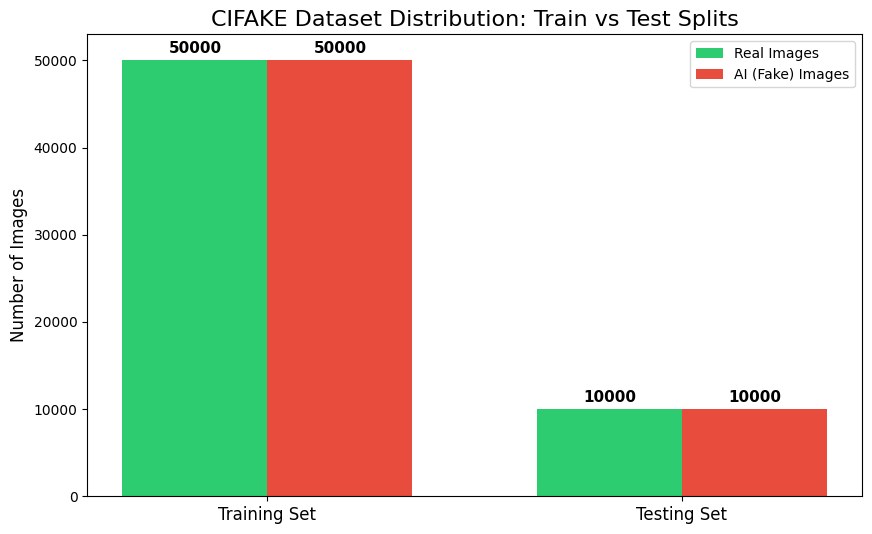

In [6]:
# CELL 4: Plot Dataset Balance
categories = ['Training Set', 'Testing Set']
real_counts = [train_real_count, test_real_count]
fake_counts = [train_fake_count, test_fake_count]

x = range(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar([i - width/2 for i in x], real_counts, width, label='Real Images', color='#2ecc71')
bars2 = plt.bar([i + width/2 for i in x], fake_counts, width, label='AI (Fake) Images', color='#e74c3c')

plt.title('CIFAKE Dataset Distribution: Train vs Test Splits', fontsize=16)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(x, categories, fontsize=12)
plt.legend()

# Add the numbers on top of the bars
for bar in bars1 + bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylim(0, max(train_real_count, train_fake_count) + 3000) # Give some headroom for the text
plt.show()

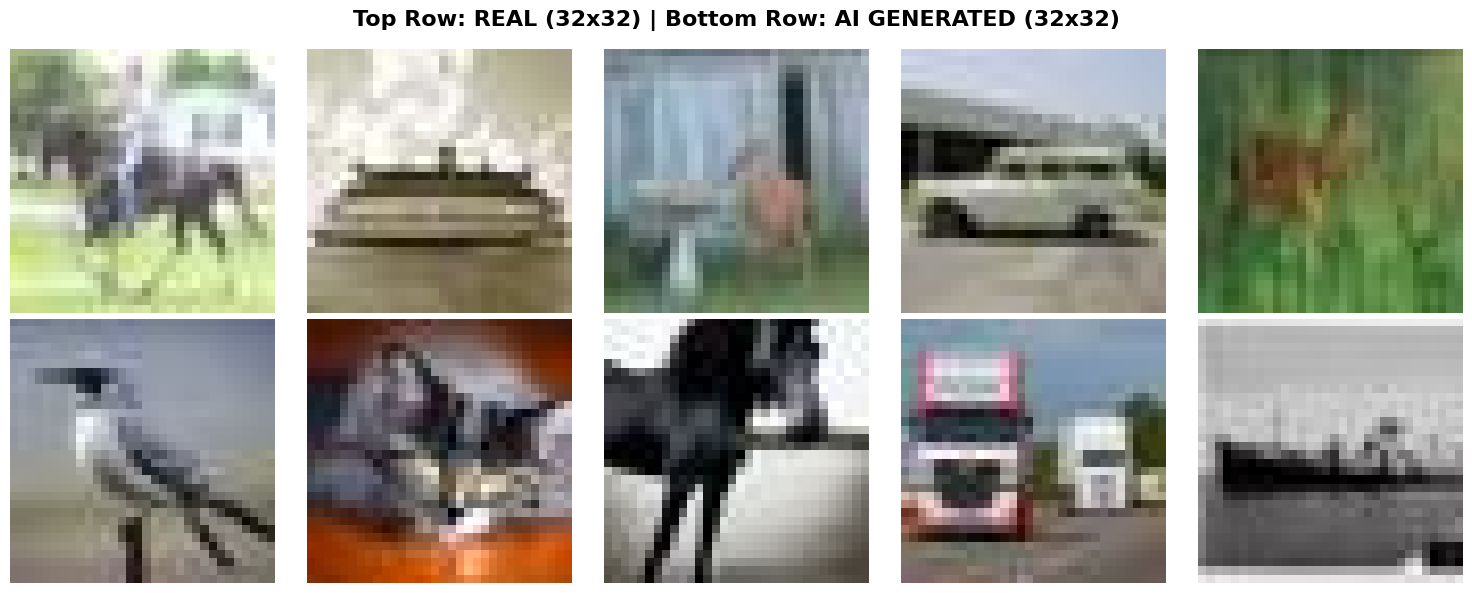

💡 Note: These images are intentionally small (32x32 pixels).


In [7]:
# CELL 5: Visualize Sample Images
def plot_cifake_samples(real_dir, fake_dir, num_samples=5):
    # Get random file names
    real_files = random.sample(os.listdir(real_dir), num_samples)
    fake_files = random.sample(os.listdir(fake_dir), num_samples)

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    fig.suptitle("Top Row: REAL (32x32) | Bottom Row: AI GENERATED (32x32)", fontsize=16, fontweight='bold')

    # Plot Real Images
    for i in range(num_samples):
        img_path = os.path.join(real_dir, real_files[i])
        img = mpimg.imread(img_path)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')

    # Plot AI Images
    for i in range(num_samples):
        img_path = os.path.join(fake_dir, fake_files[i])
        img = mpimg.imread(img_path)
        axes[1, i].imshow(img)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualizer using the training folders
plot_cifake_samples(train_real_dir, train_fake_dir)
print("💡 Note: These images are intentionally small (32x32 pixels).")

In [8]:
# CELL 6: Create Data Loaders
import tensorflow as tf

BATCH_SIZE = 64
IMG_SIZE = (32, 32)

print("Loading Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'train'),
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb'
)

print("\nLoading Testing Data...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'test'),
    shuffle=False, # We don't need to shuffle test data
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb'
)

# Optimize data loading for speed
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Data pipelines are ready!")

Loading Training Data...
Found 100000 files belonging to 2 classes.

Loading Testing Data...
Found 20000 files belonging to 2 classes.
✅ Data pipelines are ready!


In [9]:
# CELL 7: Build the Model Architecture
from tensorflow.keras import models, layers

# Build a simple but effective CNN
model = models.Sequential([
    # Input layer and first scanning pass
    layers.Rescaling(1./255, input_shape=(32, 32, 3)), # Normalize pixel values to be between 0 and 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second scanning pass (looking for more complex patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third scanning pass
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten the 2D image data into a 1D list of numbers
    layers.Flatten(),

    # Final decision layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # This prevents the model from "memorizing" the data (Overfitting)
    layers.Dense(1, activation='sigmoid') # Outputs a single number between 0 and 1
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()
print("✅ Model architecture built and compiled!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,985 (476.50 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 0 (0.00 B)

✅ Model architecture built and compiled!


In [10]:
# CELL 8: Train the Model
EPOCHS = 10

print(f"🚀 Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)
print("✅ Training Complete!")

🚀 Starting training for 10 epochs...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 256s 162ms/step - accuracy: 0.8353 - loss: 0.3723 - val_accuracy: 0.8960 - val_loss: 0.2612
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 130s 83ms/step - accuracy: 0.9030 - loss: 0.2461 - val_accuracy: 0.9172 - val_loss: 0.2077
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 82ms/step - accuracy: 0.9196 - loss: 0.2091 - val_accuracy: 0.9233 - val_loss: 0.1897
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 82ms/step - accuracy: 0.9302 - loss: 0.1844 - val_accuracy: 0.9189 - val_loss: 0.2005
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 83ms/step - accuracy: 0.9355 - loss: 0.1685 - val_accuracy: 0.9283 - val_loss: 0.1803
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 84ms/step - accuracy: 0.9427 - loss: 0.1518 - val_accuracy: 0.9282 - val_loss: 0.1859
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 82ms/step - accuracy: 0.9463 - loss: 0.1411 - val_accuracy: 0.9305 - val_loss: 0.1767
Epoch 8/10
1563/1563 ━━━━━━━━━━

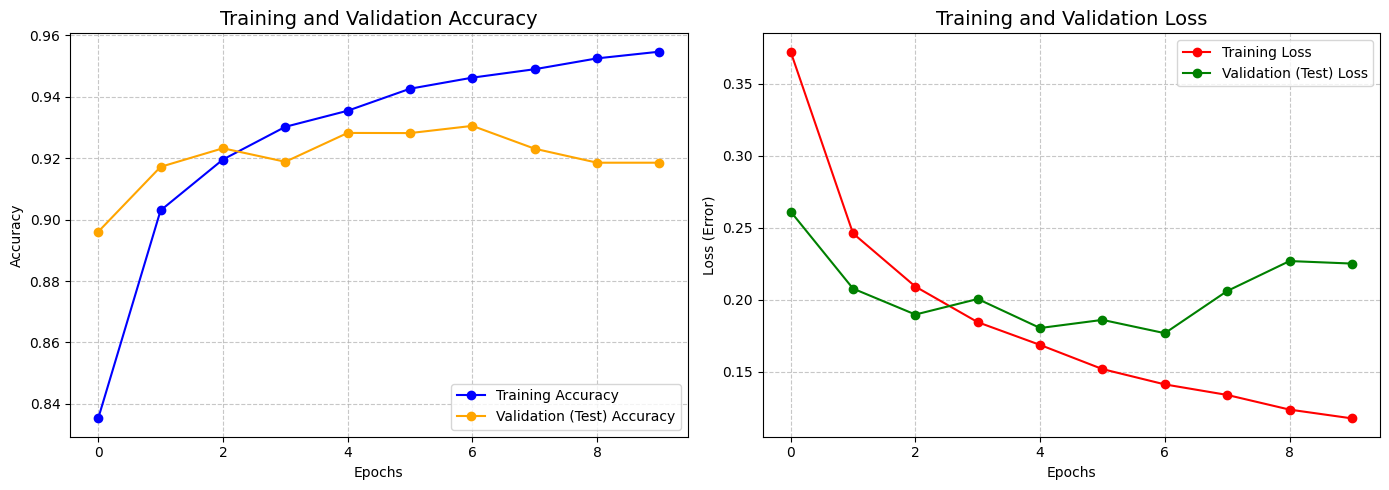

In [11]:
# CELL 9: Plot Training Results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation (Test) Accuracy', color='orange', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation (Test) Loss', color='green', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss (Error)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
# CELL 10: Save Model and Test Custom Image
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files

# 1. Save the model to a file
model.save('cifake_classifier.h5')
print("✅ Model successfully saved as 'cifake_classifier.h5'")

# 2. Upload an image to test
print("\n👇 Upload an image from your computer to test the model:")
uploaded = files.upload()

# Keras sorts folders alphabetically.
# Folder 'FAKE' comes before 'REAL'. So, FAKE = Class 0, REAL = Class 1.
for filename in uploaded.keys():
    # Load and format the image exactly how the model expects it (32x32)
    img = image.load_img(filename, target_size=(32, 32))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0 # Normalize
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    # Make the prediction
    prediction = model.predict(img_array)[0][0]

    # Interpret the math
    if prediction > 0.5:
        result = "REAL"
        confidence = prediction * 100
    else:
        result = "AI GENERATED"
        confidence = (1 - prediction) * 100

    print(f"\n🧠 MODEL PREDICTION: This image is {result}!")
    print(f"📊 Confidence: {confidence:.2f}%")

✅ Model successfully saved as 'cifake_classifier.h5'

👇 Upload an image from your computer to test the model:


Saving image.png to image.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

🧠 MODEL PREDICTION: This image is REAL!
📊 Confidence: 100.00%
